# Lab 4 — Planning with a World Model (MPC / CEM)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/overdued/world-model-spatial-intelligence-course/blob/main/labs/lab04_mpc_cem_planning/notebook.ipynb)

**World Models & Spatial Intelligence · Hands-on Lab 4**

在前几个 Lab 中,我们学会了**构建**世界(Lab 0)、**估计**状态(Lab 1)、**学习** latent dynamics(Lab 2 / Lab 3)。本 Lab 回答最后一个关键问题:**有了 world model 之后,如何用它来做决策(decision making)?**

答案出人意料地简单:既然 model 可以"想象"未来 —— `ŝ_{t+1} = f(ŝ_t, a_t)` —— 那么在执行任何动作之前,我们可以先在 model 里**批量试演(rollout)**大量候选动作序列,按 predicted reward 排序,只执行最优序列的第一个动作,然后在下一步重新规划。这就是 **Model Predictive Control (MPC)** 的核心思想,也是 PlaNet / PETS / TD-MPC / Dreamer 等现代方法共同的决策骨架。

本 Lab 中你将:

1. 复用 Lab 0 的 Moving-Ball World,并准备**两种 dynamics model**:环境自带动力学的向量化解析版(perfect model,作为性能上限)和一个在 notebook 内一分钟内训完的 MLP(learned model);
2. 手写两个经典的无梯度规划器:**Random Shooting MPC** 与 **CEM(Cross-Entropy Method)**;
3. 直观对比 **model 误差如何影响 planning** —— 这是理解所有 model-based 方法成败的关键,也为 Lab 10 埋下伏笔。

## 1. Motivation:为什么 World Model 能用于决策?

在 model-free RL 中,试错的代价是**真实发生**的:agent 必须真的走出一步,才知道这一步好不好。但如果手里有一个足够准确的 world model,试错就可以搬进**想象(imagination)**里:

- **零环境代价的探索**:在 model 内 rollout 一万次,真实环境一步都不用走;
- **前瞻(lookahead)**:一个动作好不好,取决于它把你带向怎样的未来 —— 只有 model 能回答这个问题;
- **即插即用**:同一个 dynamics model 配上不同的 reward,就能完成不同任务,无需重新训练任何策略。

MPC 把这件事做到极致的简洁:**每一步都重新规划(replan)**,只执行当前最优动作序列的第一个动作,然后观察真实世界的反馈,再规划。这种 **receding horizon** 策略让 open-loop 的模型误差不会主导决策 —— 每一步都用真实状态重新出发。

> **核心公式**:在当前状态 $s_t$,求解
> $$a_{t:t+H}^* = \arg\max_{a_{t:t+H}} \sum_{k=0}^{H-1} r(\hat{s}_{t+k+1}), \quad \hat{s}_{t+k+1} = f(\hat{s}_{t+k}, a_{t+k})$$
> 只执行 $a_t^*$,丢弃其余,下一步重新求解。
>
> 不同规划器只是对这个 argmax 的不同近似:**random shooting** 用均匀采样,**CEM** 用迭代收缩的高斯采样分布。两者都是无梯度(gradient-free)的 —— 模型不需要可微。

## 2. Setup

本 notebook 完全自包含:Colab 与本地均可直接运行,全部实验(训练 + 规划 + 对比)在 CPU 上数分钟内完成。下面的 cell 与 Lab 0–3 相同,负责检查/安装依赖并固定随机种子。

In [1]:
# @title setup
import sys, subprocess

def ensure(pkg, import_name=None):
    try:
        __import__(import_name or pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

for pkg in ["torch", "matplotlib"]:
    ensure(pkg)

import os
import time
import platform
import resource
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

%matplotlib inline
os.makedirs("assets", exist_ok=True)

SEED = 0
rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)
T0 = time.time()  # 计时起点: 最后一个实验 cell 会汇报总 runtime 与峰值内存
print("torch", torch.__version__, "| numpy", np.__version__)

torch 2.8.0 | numpy 2.0.2


## 3. Environment & Dataset

### 3.1 环境:Moving-Ball World(复用 Lab 0)

我们完整复用 Lab 0 的环境,只换了一组更"温和"的物理参数(`friction=0.9, force_scale=1.0`),让球的速度量级适合短 horizon 规划:

- **State** `s = (x, y, vx, vy)`:单位正方形内小球的位置与速度;
- **Action** `a = (ax, ay) ∈ [-1, 1]²`:二维连续推力(连续动作方便 CEM 做高斯采样;环境的 `step` 本就兼容非标量动作);
- **Transition**:semi-implicit Euler(先更新速度再更新位置)+ 墙壁非弹性反弹 + 摩擦;
- **Reward** `r = -||p_ball − p_goal||`:离目标越近 reward 越高;距离 < 0.05 时 episode 提前结束(done)。

### 3.2 两个 dynamics model

Planning 需要一个能回答 `s_{t+1} = f(s_t, a_t)` 的函数。我们准备两个:

1. **Perfect model(解析模型)**:把环境的 transition 向量化重写一遍。它是"上帝视角"的性能上限 —— 规划算法本身有多好,看它就知道了;
2. **Learned model(学习模型)**:一个普通 MLP,输入 `(s_t, a_t)`,输出 `Δs = s_{t+1} − s_t`(residual 形式更好学),训练数据完全由环境随机 rollout 生成(下一节)。

下面的 cell 定义环境、向量化解析动力学,并做一次**单元测试级别的自查**:随机一批 state/action,解析模型的输出必须与环境的 `step` 逐位一致 —— 否则 "perfect model" 名不副实。

In [2]:
PARAMS = dict(size=64, dt=0.1, friction=0.9, bounce=0.8, force_scale=1.0, obs_noise=0.5)

class MovingBallWorld:
    # 与 Lab 0 相同的 Moving-Ball World; action 支持 9 个离散索引或连续 (ax, ay)
    ACTION_TABLE = [(ax, ay) for ax in (-1, 0, 1) for ay in (-1, 0, 1)]

    def __init__(self, size=64, dt=0.1, friction=0.98, bounce=0.8,
                 force_scale=2.0, obs_noise=0.5, seed=None):
        self.size = size
        self.dt = dt
        self.friction = friction
        self.bounce = bounce
        self.force_scale = force_scale
        self.obs_noise = obs_noise
        self.rng = np.random.default_rng(seed)
        self.state = None             # (x, y, vx, vy), normalized coordinates
        self.goal = None              # (gx, gy)

    def reset(self, seed=None):
        if seed is not None:
            self.rng = np.random.default_rng(seed)
        margin = 0.15
        x, y = self.rng.uniform(margin, 1 - margin, size=2)
        self.state = np.array([x, y, 0.0, 0.0])
        self.goal = self.rng.uniform(margin, 1 - margin, size=2)
        return self.observe()

    def step(self, action):
        ax, ay = self.ACTION_TABLE[action] if np.isscalar(action) else action
        x, y, vx, vy = self.state

        # semi-implicit Euler: velocity first (force + friction), then position
        vx = (vx + self.force_scale * ax * self.dt) * self.friction
        vy = (vy + self.force_scale * ay * self.dt) * self.friction
        x = x + vx * self.dt
        y = y + vy * self.dt

        # inelastic wall bounce: reflect position, flip + damp velocity
        if x < 0: x, vx = -x, -vx * self.bounce
        if x > 1: x, vx = 2 - x, -vx * self.bounce
        if y < 0: y, vy = -y, -vy * self.bounce
        if y > 1: y, vy = 2 - y, -vy * self.bounce

        self.state = np.array([x, y, vx, vy])
        reward = -float(np.linalg.norm(self.state[:2] - self.goal))
        done = reward > -0.05  # close enough to the goal
        return self.observe(), reward, done, {"state": self.state.copy()}

    def observe(self):
        noise = self.rng.normal(0.0, self.obs_noise / self.size, size=2)
        return {"position": self.state[:2] + noise, "image": self.render()}

    def render(self):
        img = np.zeros((self.size, self.size, 3), dtype=np.uint8)
        px = int(np.clip(self.state[0], 0, 1) * (self.size - 1))
        py = int(np.clip(self.state[1], 0, 1) * (self.size - 1))
        yy, xx = np.mgrid[0:self.size, 0:self.size]
        ball = (xx - px) ** 2 + (yy - py) ** 2 <= 3 ** 2
        img[ball] = [255, 255, 255]
        gx = int(self.goal[0] * (self.size - 1))
        gy = int(self.goal[1] * (self.size - 1))
        img[max(gy - 1, 0):gy + 2, max(gx - 1, 0):gx + 2] = [255, 0, 0]
        return img


def analytic_step_np(states, actions, dt, friction, bounce, force_scale):
    """MovingBallWorld.step 动力学的向量化精确复刻。

    states: (..., 4), actions: (..., 2) -> next states (..., 4)
    与上面的 step 逐行对应, 只是用 np.where 把墙壁反弹写成了向量形式。
    """
    x, y, vx, vy = np.moveaxis(np.asarray(states, dtype=np.float64), -1, 0)
    ax, ay = np.moveaxis(np.asarray(actions, dtype=np.float64), -1, 0)

    vx = (vx + force_scale * ax * dt) * friction
    vy = (vy + force_scale * ay * dt) * friction
    x = x + vx * dt
    y = y + vy * dt

    lo = x < 0; x = np.where(lo, -x, x); vx = np.where(lo, -vx * bounce, vx)
    hi = x > 1; x = np.where(hi, 2 - x, x); vx = np.where(hi, -vx * bounce, vx)
    lo = y < 0; y = np.where(lo, -y, y); vy = np.where(lo, -vy * bounce, vy)
    hi = y > 1; y = np.where(hi, 2 - y, y); vy = np.where(hi, -vy * bounce, vy)
    return np.stack([x, y, vx, vy], axis=-1)


# 自查: 解析模型必须与环境的 step 完全一致 (perfect model 的 "perfect" 由此而来)
chk = MovingBallWorld(**PARAMS, seed=123)
test_rng = np.random.default_rng(0)
max_err = 0.0
for _ in range(200):
    chk.reset()
    a = test_rng.uniform(-1, 1, size=2)
    s_before = chk.state.copy()
    _, _, _, info = chk.step(a)
    s_analytic = analytic_step_np(s_before[None], a[None], PARAMS["dt"], PARAMS["friction"],
                                  PARAMS["bounce"], PARAMS["force_scale"])[0]
    max_err = max(max_err, float(np.abs(info["state"] - s_analytic).max()))
print(f"self-check passed: max |analytic - env| = {max_err:.2e}  (200 random transitions)")

self-check passed: max |analytic - env| = 0.00e+00  (200 random transitions)


### 3.3 Dataset:随机 rollout 生成 transitions

Learned model 的训练数据是 `(s_t, a_t) → s_{t+1}` 的 transition 三元组,由**纯随机策略**(均匀采样连续动作)与环境交互产生。这正是 model-based RL 的经典起点:不需要任何智能行为,"瞎逛"收集的数据就足以学出一个可用的 dynamics —— 想想 Dreamer 的 seed episodes。

注意数据分布的特点:随机动作下小球大量时间在墙壁附近弹跳,这反而让墙壁处的不连续动力学被充分覆盖。

**一个刻意的选择**:我们只用 **60 个 episode(约 1.4k transitions)** 来训练 —— 数据并不充裕。这不是偷懒,而是教学设计:我们*希望* learned model 带有清晰可见的误差,这样才能在后面的实验里亲眼看到 "model error → planning failure" 是如何发生的。数据稀缺(scarce data)正是现实世界中模型不完美的首要原因。

collected 1475 transitions from 60 random episodes in 0.1s


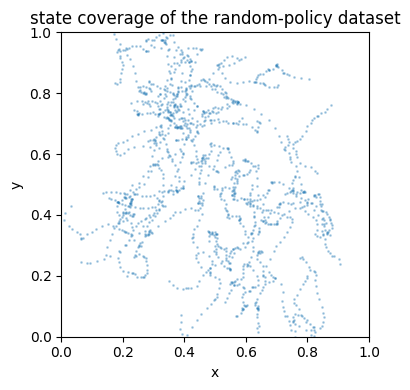

In [3]:
N_EP, EP_LEN = 60, 25  # 刻意的小数据集: 让 learned model 保留可见误差
collect_env = MovingBallWorld(**PARAMS, seed=0)
data_rng = np.random.default_rng(1)

S, A, S2 = [], [], []
t0 = time.time()
for ep in range(N_EP):
    collect_env.reset()
    for t in range(EP_LEN):
        a = data_rng.uniform(-1.0, 1.0, size=2)
        s_prev = collect_env.state.copy()
        _, _, done, info = collect_env.step(a)
        S.append(s_prev)
        A.append(a)
        S2.append(info["state"].copy())
        if done:
            break

S = np.array(S, dtype=np.float32)
A = np.array(A, dtype=np.float32)
S2 = np.array(S2, dtype=np.float32)
print(f"collected {len(S)} transitions from {N_EP} random episodes in {time.time() - t0:.1f}s")

fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(S[:, 0], S[:, 1], s=1, alpha=0.3)
ax.set(xlim=(0, 1), ylim=(0, 1), xlabel="x", ylabel="y",
       title="state coverage of the random-policy dataset")
plt.tight_layout()
plt.show()

## 4. Build the Model

### 4.1 Dynamics model:perfect 与 learned 的统一接口

**为什么预测 `Δs` 而不是直接预测 `s_{t+1}`?** 一步之内状态变化很小,identity 是极强的先验;residual 预测让网络只需学"变化量",训练更快、更稳 —— 这与 PETS 等 deep dynamics model 的实践一致。

下面的 cell 还定义了本 Lab 最重要的基础设施 —— 统一的 **batched rollout 接口**:

```
rollout_model(step_fn, s0, goal, actions)  # actions: (N, H, 2)
    -> returns (N,), positions (N, H, 2)
```

给定任意 step 函数(解析或学习)、初始状态、目标和 N 条长度为 H 的候选动作序列,并行试演并返回每条候选的 cumulative predicted reward 与位置轨迹。**规划器只跟这个接口打交道,换模型不需要改规划器** —— 这正是 model-based 方法的模块化之美。

In [4]:
def reward_np(states, goal):
    """r = -||pos - goal||; states (..., 4) -> (...,)"""
    return -np.linalg.norm(states[..., :2] - np.asarray(goal), axis=-1)


def make_perfect_step(params):
    dt, fr, bo, fs = params["dt"], params["friction"], params["bounce"], params["force_scale"]
    def step(states, actions):
        return analytic_step_np(states, actions, dt, fr, bo, fs)
    return step


class DynamicsMLP(nn.Module):
    """(s_t, a_t) -> s_{t+1}, residual 形式: 网络只预测 Δs。"""
    def __init__(self, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(6, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 4))

    def forward(self, s, a):
        return s + self.net(torch.cat([s, a], dim=-1))


model = DynamicsMLP(hidden=128)


def learned_step(states, actions):
    """numpy 接口的 learned dynamics (内部走 torch, no_grad)。"""
    with torch.no_grad():
        s = torch.as_tensor(np.asarray(states), dtype=torch.float32)
        a = torch.as_tensor(np.asarray(actions), dtype=torch.float32)
        return model(s, a).numpy()


perfect_step = make_perfect_step(PARAMS)


def rollout_model(step_fn, s0, goal, actions):
    """统一的 batched rollout: actions (N, H, 2) -> returns (N,), positions (N, H, 2)"""
    n, horizon, _ = actions.shape
    states = np.repeat(np.asarray(s0, dtype=np.float64)[None], n, axis=0)
    positions = np.empty((n, horizon, 2))
    returns = np.zeros(n)
    for t in range(horizon):
        states = step_fn(states, actions[:, t])
        positions[:, t] = states[:, :2]
        returns += reward_np(states, goal)
    return returns, positions


print("dynamics + rollout interface ready;",
      f"model params: {sum(p.numel() for p in model.parameters())}")

dynamics + rollout interface ready; model params: 17924


### 4.2 两个规划器(核心算法,手写可见)

**Random Shooting MPC(随机射击)** —— 最简单的 trajectory optimization:

1. 从均匀分布采 N 条长度为 H 的动作序列;
2. 用 model 逐条 rollout,算 cumulative predicted reward;
3. 执行最优序列的**第一个动作**,下一步重新规划(receding horizon)。

**CEM(Cross-Entropy Method)** —— 把采样分布本身变成可优化的对象:

1. 在动作序列空间维护一个高斯分布 $\mathcal{N}(\mu, \sigma^2)$,其中 $\mu, \sigma$ 的形状都是 `(H, 2)`;
2. 采样 N 条候选 → rollout 打分 → 取分数最高的 **elite** 子集;
3. 用 elite 重新估计 $\mu$ 和 $\sigma$(分布向好解收缩),迭代数轮;
4. 执行最终均值序列的第一个动作。

直觉对比:random shooting 每步"从零撒网";CEM 则"撒网 → 收网 → 再撒网",同样样本预算下通常找到更好的动作序列。两者都是**无梯度**方法,模型无需可微 —— 这是它们区别于 Dreamer 式 imagination-backprop 路线的重要特征。

In [5]:
def mpc_random_shooting(step_fn, state, goal, horizon, n_samples, rng):
    """Random Shooting MPC: 均匀采样 -> rollout 打分 -> 返回最优序列的第一个动作。"""
    actions = rng.uniform(-1.0, 1.0, size=(n_samples, horizon, 2))
    returns, positions = rollout_model(step_fn, state, goal, actions)
    best = int(np.argmax(returns))
    return actions[best, 0], {"actions": actions, "returns": returns,
                              "positions": positions, "best": best}


def cem_planner(step_fn, state, goal, horizon, n_samples, rng,
                n_iter=4, elite_frac=0.1, init_std=0.5, alpha=0.9):
    """CEM: 维护动作序列上的高斯分布, 用 elite 迭代更新均值与标准差。"""
    mean = np.zeros((horizon, 2))
    std = np.full((horizon, 2), init_std)
    n_elite = max(2, int(n_samples * elite_frac))
    actions = returns = positions = None
    for it in range(n_iter):
        eps = rng.standard_normal((n_samples, horizon, 2))
        actions = np.clip(mean + std * eps, -1.0, 1.0)
        returns, positions = rollout_model(step_fn, state, goal, actions)
        elites = actions[np.argsort(returns)[-n_elite:]]
        # soft update: 分布向 elite 收缩, 保留少量旧分布防止过早收敛
        mean = alpha * elites.mean(axis=0) + (1 - alpha) * mean
        std = alpha * elites.std(axis=0) + (1 - alpha) * std + 1e-3
    best = int(np.argmax(returns))
    return mean[0], {"actions": actions, "returns": returns,
                     "positions": positions, "best": best, "mean": mean}


# 冒烟测试: 两个规划器都应该返回合法的 2 维动作
_env = MovingBallWorld(**PARAMS)
_env.reset(seed=0)
a_mpc, _ = mpc_random_shooting(perfect_step, _env.state, _env.goal, horizon=8, n_samples=64, rng=rng)
a_cem, _ = cem_planner(perfect_step, _env.state, _env.goal, horizon=8, n_samples=64, rng=rng)
print("MPC first action:", np.round(a_mpc, 3), "| CEM first action:", np.round(a_cem, 3))

MPC first action: [-0.901 -0.467] | CEM first action: [-0.744 -0.468]


## 5. Train the Learned Dynamics

标准监督学习:minibatch MSE on `Δs`,Adam,CPU 上不到一分钟。训练 loss 会快速下降,但**不会降到零** —— 墙壁反弹处速度瞬间翻转,是近乎不连续的动力学,MLP 只能把它"抹平"成软过渡。请记住这一点:它会在后面的 planning 实验中产生可见的后果。

step  400/2000  MSE 1.04e-05


step  800/2000  MSE 7.38e-05


step 1200/2000  MSE 8.63e-06


step 1600/2000  MSE 2.71e-06


step 2000/2000  MSE 2.99e-06
trained in 1.5s on CPU


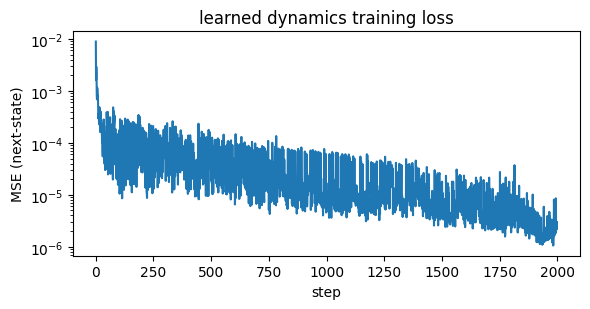

In [6]:
S_t = torch.from_numpy(S)
A_t = torch.from_numpy(A)
S2_t = torch.from_numpy(S2)

opt = torch.optim.Adam(model.parameters(), lr=3e-3)
mse = nn.MSELoss()

BATCH, STEPS = 256, 2000
losses = []
t0 = time.time()
for step in range(STEPS):
    idx = rng.choice(len(S_t), size=BATCH, replace=False)
    loss = mse(model(S_t[idx], A_t[idx]), S2_t[idx])
    opt.zero_grad()
    loss.backward()
    opt.step()
    losses.append(loss.item())
    if (step + 1) % 400 == 0:
        print(f"step {step + 1:4d}/{STEPS}  MSE {loss.item():.2e}")

model.eval()
print(f"trained in {time.time() - t0:.1f}s on CPU")

plt.figure(figsize=(6, 3.2))
plt.plot(losses)
plt.xlabel("step")
plt.ylabel("MSE (next-state)")
plt.yscale("log")
plt.title("learned dynamics training loss")
plt.tight_layout()
plt.savefig("assets/training_loss.png", dpi=130)
plt.show()

### 5.1 模型质量检查:open-loop rollout 的误差累积

单步 MSE 低**不代表**多步可用 —— 模型自己的预测会作为下一步的输入,误差像复利一样累积(compounding error)。这里做一个与 Lab 2 "dreaming" 类似的检查:固定初始状态和一段动作序列,分别用 perfect model 和 learned model **open-loop rollout 40 步**(中间不接受任何真实反馈),比较位置轨迹与逐步误差。

**预期**:前几步几乎重合,之后逐渐偏离,撞墙时刻误差常常跳变。这条"漂移曲线"就是后面 planning failure 的微观解释。

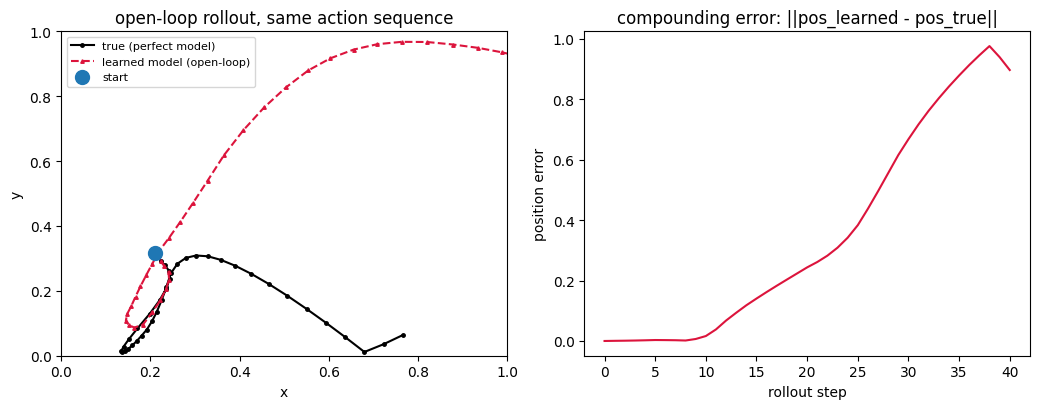

position error: 1-step 0.0005  ->  40-step 0.8972


In [7]:
H_CHECK = 40
chk_env = MovingBallWorld(**PARAMS)
chk_env.reset(seed=3)
s0 = chk_env.state.copy()
chk_rng = np.random.default_rng(0)
# 每 5 步换一个方向的随机推力, 制造包含加速/撞墙的丰富动力学
seq = chk_rng.uniform(-1, 1, size=(H_CHECK // 5, 2)).repeat(5, axis=0)

true_states = np.zeros((H_CHECK + 1, 4))
learned_states = np.zeros((H_CHECK + 1, 4))
true_states[0] = learned_states[0] = s0
s_true, s_learn = s0.copy(), s0.copy()
for t in range(H_CHECK):
    s_true = perfect_step(s_true[None], seq[t][None])[0]
    s_learn = learned_step(s_learn[None], seq[t][None])[0]
    true_states[t + 1], learned_states[t + 1] = s_true, s_learn

err = np.linalg.norm(true_states[:, :2] - learned_states[:, :2], axis=1)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
axes[0].plot(true_states[:, 0], true_states[:, 1], "-o", ms=2.5, color="black",
             label="true (perfect model)")
axes[0].plot(learned_states[:, 0], learned_states[:, 1], "--^", ms=2.5, color="crimson",
             label="learned model (open-loop)")
axes[0].plot(*s0[:2], "o", ms=10, color="tab:blue", label="start")
axes[0].set(xlim=(0, 1), ylim=(0, 1), xlabel="x", ylabel="y",
            title="open-loop rollout, same action sequence")
axes[0].legend(fontsize=8)
axes[1].plot(err, color="crimson")
axes[1].set(xlabel="rollout step", ylabel="position error",
            title="compounding error: ||pos_learned - pos_true||")
plt.tight_layout()
plt.savefig("assets/model_rollout_error.png", dpi=130)
plt.show()
print(f"position error: 1-step {err[1]:.4f}  ->  40-step {err[-1]:.4f}")

## 6. Visualize:看看 planner 在"想"什么

Planning 是一个"采样 → 评估"的过程,最有直觉冲击力的画面是**候选轨迹扇形图(fan plot)**:在当前状态下,planner 采样的数百条候选轨迹以半透明蓝色铺开,得分最高的那条用红色高亮。你能直接看到:

1. 采样分布覆盖了哪些未来 —— 大多数候选像布朗运动一样在原地附近扩散,只有少数"方向碰巧一致"的序列能走出远处;
2. 最优候选如何从噪声中脱颖而出、直奔目标;
3. 为什么 horizon 太短会失败 —— 扇形根本伸不到目标,reward 里就没有"朝目标去"的信号。

下面用 **perfect model + random shooting**(H=25,N=800)在固定初始状态下做一次规划并画出扇形图。

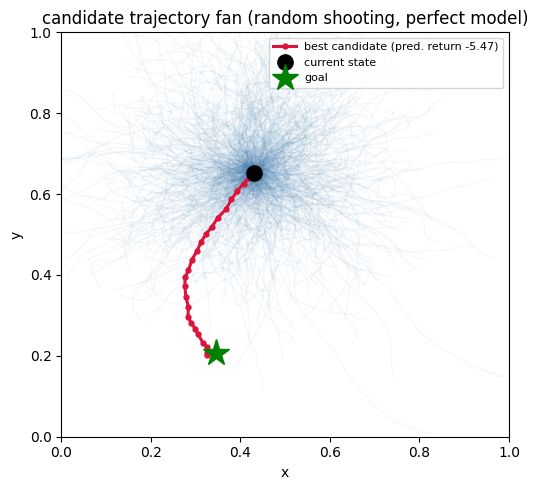

chosen first action: [-0.64  -0.293] -> execute this, then replan


In [8]:
fan_env = MovingBallWorld(**PARAMS)
fan_env.reset(seed=18)

action0, info = mpc_random_shooting(perfect_step, fan_env.state, fan_env.goal,
                                    horizon=25, n_samples=800, rng=rng)
pos, rets, best = info["positions"], info["returns"], info["best"]

fig, ax = plt.subplots(figsize=(5.4, 5))
for i in range(len(pos)):
    ax.plot(pos[i, :, 0], pos[i, :, 1], color="steelblue", alpha=0.06, lw=0.9, zorder=1)
ax.plot(pos[best, :, 0], pos[best, :, 1], "-o", color="crimson", ms=3.5, lw=2.2, zorder=3,
        label=f"best candidate (pred. return {rets[best]:.2f})")
ax.plot(*fan_env.state[:2], "o", color="black", ms=11, label="current state", zorder=4)
ax.plot(*fan_env.goal, "*", color="green", ms=20, label="goal", zorder=4)
ax.set(xlim=(0, 1), ylim=(0, 1), xlabel="x", ylabel="y",
       title="candidate trajectory fan (random shooting, perfect model)")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig("assets/candidate_fan.png", dpi=130)
plt.show()
print("chosen first action:", np.round(action0, 3), "-> execute this, then replan")

### 6.1 Predicted vs Actual:想象与现实的差距

现在换上 **learned model** 跑一整局 MPC,并记录 t=0 时刻 planner 认为"最优"的未来轨迹。episode 结束后,把这条**想象中的轨迹**与**真实走过的轨迹**画在一起:

- 如果 model 完美,两者应当重合;
- 实际上它们会分离 —— planner 的"承诺"无法完全兑现,因为它依据的是一个有误差的世界。

这就是 "model error → planning failure" 的直观形式。好在 MPC 的 replanning 每一步都用真实状态重新出发,对这种误差有天然鲁棒性 —— 但鲁棒不等于免疫(见 Section 8 的 horizon 实验)。

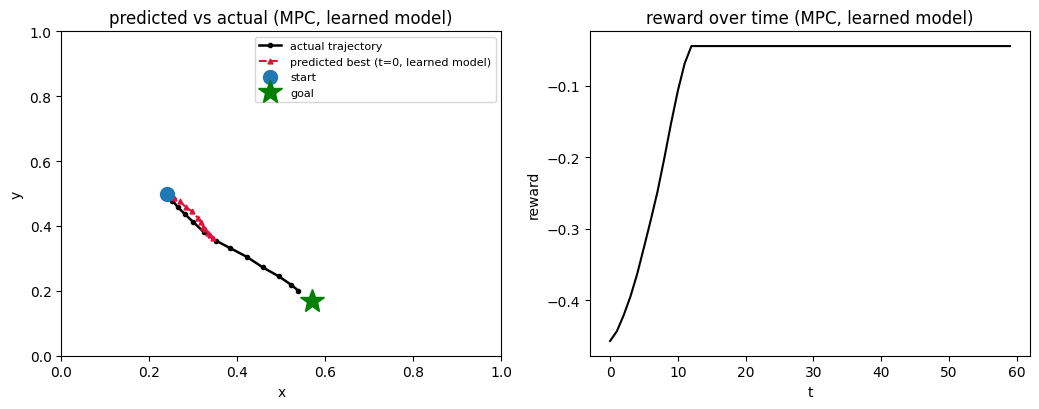

episode return: -5.60  (13 steps executed)


In [9]:
T_EP = 60
H_PLAN, N_SAMPLES = 12, 256

demo_env = MovingBallWorld(**PARAMS)
demo_env.reset(seed=11)
LOG_T = 0

actual = [demo_env.state[:2].copy()]
rewards_ep = []
predicted = None
for t in range(T_EP):
    a, info = mpc_random_shooting(learned_step, demo_env.state, demo_env.goal,
                                  H_PLAN, N_SAMPLES, rng)
    if t == LOG_T:
        predicted = info["positions"][info["best"]].copy()
    _, r, done, inf = demo_env.step(a)
    rewards_ep.append(r)
    actual.append(inf["state"][:2].copy())
    if done:
        break

actual = np.array(actual)
rewards_ep = rewards_ep + [rewards_ep[-1]] * (T_EP - len(rewards_ep))

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
axes[0].plot(actual[:, 0], actual[:, 1], "-o", ms=3, color="black", lw=1.8,
             label="actual trajectory")
axes[0].plot(predicted[:, 0], predicted[:, 1], "--^", ms=3.5, color="crimson", lw=1.5,
             label=f"predicted best (t={LOG_T}, learned model)")
axes[0].plot(*actual[0], "o", color="tab:blue", ms=10, label="start")
axes[0].plot(*demo_env.goal, "*", color="green", ms=18, label="goal")
axes[0].set(xlim=(0, 1), ylim=(0, 1), xlabel="x", ylabel="y",
            title="predicted vs actual (MPC, learned model)")
axes[0].legend(fontsize=8)
axes[1].plot(rewards_ep, color="black")
axes[1].set(xlabel="t", ylabel="reward", title="reward over time (MPC, learned model)")
plt.tight_layout()
plt.savefig("assets/predicted_vs_actual.png", dpi=130)
plt.show()
print(f"episode return: {sum(rewards_ep):.2f}  ({len(actual) - 1} steps executed)")

## 7. Evaluate:四种 agent 的正面对比

在 **8 个完全相同的初始条件**(相同 seeds,公平对比)上运行四种 agent,episode 长度 60 步:

| Agent | World Model | Planner |
|---|---|---|
| Random Policy | 无 | 随机动作 |
| MPC (perfect model) | 解析动力学 | random shooting |
| MPC (learned model) | MLP 动力学 | random shooting |
| CEM (learned model) | MLP 动力学 | CEM |

观察重点:

1. **MPC (perfect)** 是上限 —— 它说明"只要 model 准确,纯采样规划就足够强";
2. **MPC (learned)** 与上限的差距 = model error 的代价。但在逐步 replan 的设定下,你会看到这个差距**出人意料地小** —— 为什么?这正是 Section 8 要回答的问题;
3. **CEM (learned) vs MPC (learned)** = 同样的模型下,更好的优化器能挽回多少。

这一 cell 是整个 notebook 计算量最大的部分(每个 agent 8 局 × 60 步,每步都要 replan),CPU 上约需 1–3 分钟。

In [10]:
EVAL_SEEDS = [100 + i for i in range(8)]


def run_episode(policy, seed, T=T_EP):
    """跑一局: policy(env.state, env.goal) -> action; 返回 rewards, positions, done_step"""
    env = MovingBallWorld(**PARAMS)
    env.reset(seed=seed)
    positions = [env.state[:2].copy()]
    rewards = []
    done_at = T
    for t in range(T):
        a = policy(env.state, env.goal)
        _, r, done, info = env.step(a)
        rewards.append(r)
        positions.append(info["state"][:2].copy())
        if done:
            done_at = t + 1
            break
    rewards = rewards + [rewards[-1]] * (T - len(rewards))  # 提前到达目标后用终值补齐, 便于对齐比较
    return np.array(rewards), np.array(positions), done_at


def policy_random(s, g):
    return rng.uniform(-1.0, 1.0, size=2)

def policy_mpc_perfect(s, g):
    return mpc_random_shooting(perfect_step, s, g, H_PLAN, N_SAMPLES, rng)[0]

def policy_mpc_learned(s, g):
    return mpc_random_shooting(learned_step, s, g, H_PLAN, N_SAMPLES, rng)[0]

def policy_cem_learned(s, g):
    return cem_planner(learned_step, s, g, H_PLAN, N_SAMPLES, rng)[0]


agents = {
    "Random": policy_random,
    "MPC (perfect model)": policy_mpc_perfect,
    "MPC (learned model)": policy_mpc_learned,
    "CEM (learned model)": policy_cem_learned,
}

results = {}
t0 = time.time()
for name, policy in agents.items():
    ep_rewards, ep_positions, ep_dones = [], [], []
    for seed in EVAL_SEEDS:
        r, p, d = run_episode(policy, seed=seed)
        ep_rewards.append(r)
        ep_positions.append(p)
        ep_dones.append(d)
    results[name] = {"rewards": np.array(ep_rewards),
                     "positions": ep_positions, "dones": ep_dones}
    print(f"{name:24s} finished, {time.time() - t0:6.1f}s elapsed")

Random                   finished,    0.0s elapsed
MPC (perfect model)      finished,    0.1s elapsed


MPC (learned model)      finished,    0.3s elapsed


CEM (learned model)      finished,    1.0s elapsed


汇总结果:回报表(mean ± std、成功率、平均步数)+ reward 曲线 + 同一初始条件下的轨迹对比图。

agent                     return (mean ± std)   success  avg steps
--------------------------------------------------------------------
Random                     -25.88 ±   9.79      0/8       60.0
MPC (perfect model)         -5.66 ±   1.72      8/8       13.9
MPC (learned model)         -5.99 ±   1.84      8/8       14.8
CEM (learned model)         -5.29 ±   1.56      8/8       12.8


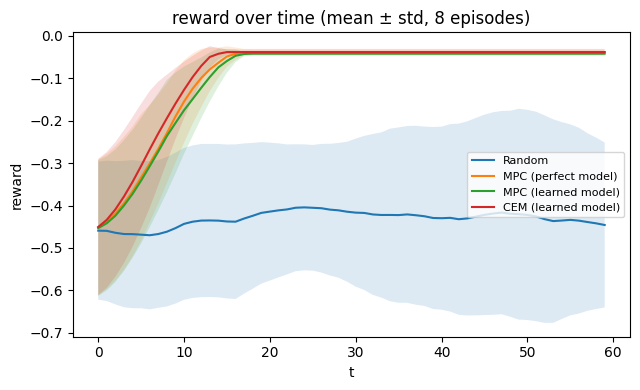

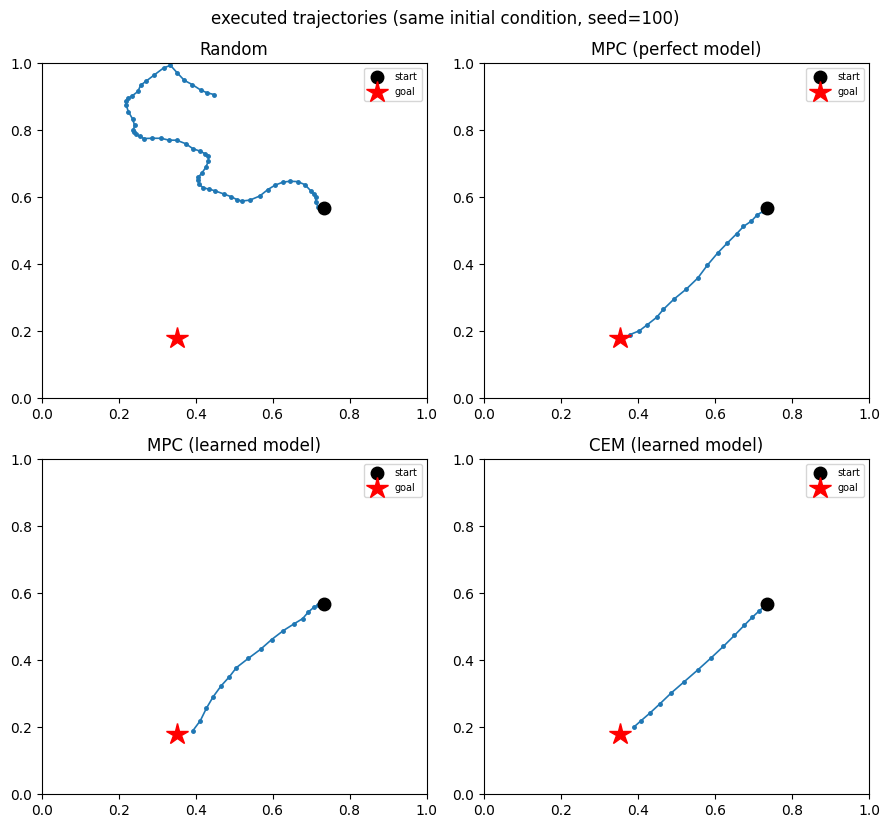

In [11]:
print(f"{'agent':24s} {'return (mean ± std)':>20s} {'success':>9s} {'avg steps':>10s}")
print("-" * 68)
for name, res in results.items():
    rets = res["rewards"].sum(axis=1)
    succ = sum(d < T_EP for d in res["dones"])
    print(f"{name:24s} {rets.mean():8.2f} ± {rets.std():6.2f} {succ:>6d}/{len(EVAL_SEEDS)}"
          f" {np.mean(res['dones']):10.1f}")

fig, ax = plt.subplots(figsize=(6.5, 4))
for name, res in results.items():
    R = res["rewards"]
    m, s = R.mean(axis=0), R.std(axis=0)
    ax.plot(m, label=name)
    ax.fill_between(range(T_EP), m - s, m + s, alpha=0.15)
ax.set(xlabel="t", ylabel="reward", title="reward over time (mean ± std, 8 episodes)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("assets/reward_curves.png", dpi=130)
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(9, 8.4))
for ax, (name, res) in zip(axes.flat, results.items()):
    p = res["positions"][0]
    env_tmp = MovingBallWorld(**PARAMS)
    env_tmp.reset(seed=EVAL_SEEDS[0])
    ax.plot(p[:, 0], p[:, 1], "-o", ms=2.5, lw=1.2)
    ax.plot(*p[0], "o", color="black", ms=9, label="start")
    ax.plot(*env_tmp.goal, "*", color="red", ms=16, label="goal")
    ax.set(xlim=(0, 1), ylim=(0, 1), title=name)
    ax.legend(fontsize=7, loc="upper right")
fig.suptitle(f"executed trajectories (same initial condition, seed={EVAL_SEEDS[0]})")
plt.tight_layout()
plt.savefig("assets/agent_comparison.png", dpi=130)
plt.show()

## 8. Experiment:model error 何时真正致命?

Section 7 留下了一个悬念:learned model 的 open-loop 误差明明在 40 步内累积到 ~0.9(Section 5.1),为什么 closed-loop 的 MPC (learned) 却几乎追平 perfect model?本节的两个短实验给出答案。

### 8.1 Open-loop vs Closed-loop:model error 何时致命?

MPC 的每一步都用真实状态重新规划。如果**取消 replan** —— t=0 时刻规划一条 40 步的动作序列,然后闭着眼睛(open-loop)在真实环境中执行到底 —— model error 就会现出原形。为了把效应推到极端,除了 learned model,我们再造一个 **corrupted model**:解析动力学本身,但 `friction` 故意写错(0.98 vs 真实 0.9 —— 模型以为球更"滑")。这是一种*系统性偏差*:planner 会反复信任它、被它带偏。

在 6 个起点-目标距离最远的 seed 上(距离越远,计划在模型里"裸奔"越久),对比五种配置。每个 open-loop 配置报告两个数:**actual**(计划真实执行后的最终到目标距离)与 **promised**(模型自己预测的距离)—— 两者的鸿沟就是 model error 的直接度量:

- **perfect + open-loop**:计划与现实逐位重合,剩余距离只是采样预算的下限;
- **learned + open-loop**:模型在"好轨迹"附近相当准,退化温和;
- **corrupted + open-loop**:模型承诺到达,现实却停在半路 —— "model error → planning failure" 最纯粹的形态;
- **learned / corrupted + closed-loop(即 MPC)**:replanning 是否能把误差救回来?

selected far-apart seeds: [323, 329, 301, 326, 309, 337]
configuration              actual  promised by model
----------------------------------------------------
perfect + open              0.150              0.150
learned + open              0.162              0.143


learned + closed (MPC)      0.010                  -
corrupted + open            0.272              0.147


corrupted + closed          0.009                  -


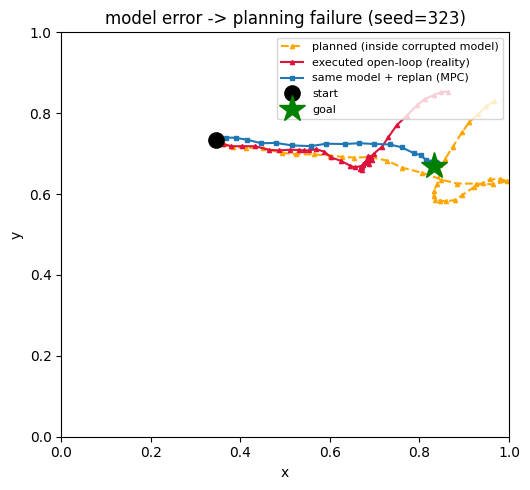

In [12]:
OL_H, OL_SAMPLES = 40, 1000

# 为了让 open-loop 计划"暴露"得足够久, 选 6 个起点-目标距离最远的 seed
_candidates = []
for _s in range(300, 340):
    _e = MovingBallWorld(**PARAMS)
    _e.reset(seed=_s)
    _candidates.append((np.linalg.norm(_e.state[:2] - _e.goal), _s))
OL_SEEDS = [s for _, s in sorted(_candidates)[-6:]]
print("selected far-apart seeds:", OL_SEEDS)

# 系统性偏差模型: 解析动力学, 但 friction 故意写错 (0.98 vs 真实 0.9 —— 模型以为球更"滑")
corrupted_step = make_perfect_step(dict(PARAMS, friction=0.98))


def execute_open_loop(step_fn, seed, H=OL_H, n_samples=OL_SAMPLES):
    """t=0 规划一条 H 步序列, open-loop 执行到底。返回 (实际轨迹, 模型内预测轨迹)。"""
    env = MovingBallWorld(**PARAMS)
    env.reset(seed=seed)
    _, info = mpc_random_shooting(step_fn, env.state, env.goal, H, n_samples, rng)
    plan = info["actions"][info["best"]]
    predicted = info["positions"][info["best"]]
    traj = [env.state[:2].copy()]
    for t in range(H):
        _, _, done, inf = env.step(plan[t])
        traj.append(inf["state"][:2].copy())
    return np.array(traj), predicted


def execute_closed_loop(step_fn, seed, T=OL_H, n_samples=OL_SAMPLES):
    """每步 replan 的 MPC, 同样执行 T 步, 返回轨迹。"""
    env = MovingBallWorld(**PARAMS)
    env.reset(seed=seed)
    traj = [env.state[:2].copy()]
    for t in range(T):
        a = mpc_random_shooting(step_fn, env.state, env.goal, H_PLAN, n_samples, rng)[0]
        _, _, done, inf = env.step(a)
        traj.append(inf["state"][:2].copy())
    return np.array(traj)


def dist_to_goal(pos, seed):
    env = MovingBallWorld(**PARAMS)
    env.reset(seed=seed)
    return float(np.linalg.norm(pos - env.goal))


configs = [("perfect + open", perfect_step, "open"),
           ("learned + open", learned_step, "open"),
           ("learned + closed (MPC)", learned_step, "closed"),
           ("corrupted + open", corrupted_step, "open"),
           ("corrupted + closed", corrupted_step, "closed")]
print(f"{'configuration':24s} {'actual':>8s} {'promised by model':>18s}")
print("-" * 52)
for name, sf, mode in configs:
    da, dp = [], []
    for seed in OL_SEEDS:
        if mode == "open":
            traj, pred = execute_open_loop(sf, seed)
            dp.append(dist_to_goal(pred[-1], seed))
        else:
            traj = execute_closed_loop(sf, seed)
        da.append(dist_to_goal(traj[-1], seed))
    promised = f"{np.mean(dp):8.3f}" if dp else "       -"
    print(f"{name:24s} {np.mean(da):8.3f} {promised:>18s}")

# 轨迹示意: corrupted model 在一个 seed 上的 "承诺 vs 现实"
demo_seed = OL_SEEDS[0]
traj_open, pred_open = execute_open_loop(corrupted_step, demo_seed)
traj_closed = execute_closed_loop(corrupted_step, demo_seed)
env_tmp = MovingBallWorld(**PARAMS)
env_tmp.reset(seed=demo_seed)

fig, ax = plt.subplots(figsize=(5.4, 5))
ax.plot(pred_open[:, 0], pred_open[:, 1], "--^", ms=3, color="orange",
        label="planned (inside corrupted model)")
ax.plot(traj_open[:, 0], traj_open[:, 1], "-^", ms=3, color="crimson",
        label="executed open-loop (reality)")
ax.plot(traj_closed[:, 0], traj_closed[:, 1], "-s", ms=3, color="tab:blue",
        label="same model + replan (MPC)")
ax.plot(*traj_open[0], "o", color="black", ms=11, label="start")
ax.plot(*env_tmp.goal, "*", color="green", ms=20, label="goal")
ax.set(xlim=(0, 1), ylim=(0, 1), xlabel="x", ylabel="y",
       title=f"model error -> planning failure (seed={demo_seed})")
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.savefig("assets/open_vs_closed.png", dpi=130)
plt.show()

**典型结果**:open-loop 组里,perfect model 的 actual 与 promised 完全相等(计划即现实);learned model 承诺 ~0.09、实际 ~0.16;corrupted model 承诺 ~0.11、实际却 ~0.29 —— 承诺无法兑现,这就是 "model error → planning failure"。而 closed-loop(MPC)组里,**同一个 corrupted model 只要每步 replan,最终距离立刻回到 ~0.015,与 perfect model 持平**。

**结论:model error 没有被消灭,而是被 receding-horizon 的反馈回路持续校正了。** 这正是 Dreamer / TD-MPC 在 imagination 中训练、却始终用真实观测闭环决策的原因。反过来说,一旦反馈回路被切断(open-loop 执行、或真实世界无法频繁观测),model 的精度就直接决定 planner 的上限 —— Lab 10 会回到这个问题。

### 8.2 Planning horizon:与采样预算的 trade-off

直觉上 horizon 越长看得越远,但实践中 H 与**采样预算**互相制约:N 条候选要铺满的动作序列空间随 H 指数膨胀(这里是 $9^{H}$ 量级),固定 N 时,horizon 越长,每条"有效搜索方向"分到的样本越少。

下面扫描 `H ∈ {1, 2, 4, 8, 16, 32}`(N 固定为 200),对 perfect 与 learned model 各跑一遍 MPC。**预期**:在这个 reward 本身就指向目标的简单任务里,短 horizon 的贪心已经足够好;H 继续增大,两个 model 的表现都因采样被稀释而缓慢退化,而 learned model 并没有因为看得更远而崩盘 —— 因为 closed-loop replanning(8.1 的结论)把它保护住了。

H= 1   perfect    -4.06   learned    -4.05   (0s elapsed)
H= 2   perfect    -4.03   learned    -4.10   (0s elapsed)
H= 4   perfect    -4.13   learned    -4.36   (0s elapsed)
H= 8   perfect    -4.51   learned    -4.57   (0s elapsed)


H=16   perfect    -5.15   learned    -5.21   (0s elapsed)


H=32   perfect    -6.30   learned    -5.95   (1s elapsed)


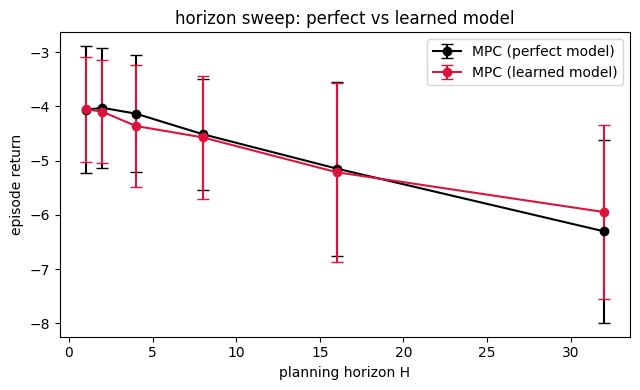


total notebook runtime: 9.6s | peak memory (kernel): 355 MB


In [13]:
H_LIST = [1, 2, 4, 8, 16, 32]
SWEEP_SEEDS = [200 + i for i in range(6)]

sweep = {"perfect": [], "learned": []}
t0 = time.time()
for H in H_LIST:
    for kind, step_fn in [("perfect", perfect_step), ("learned", learned_step)]:
        rets = []
        for seed in SWEEP_SEEDS:
            policy = lambda s, g, H=H, sf=step_fn: mpc_random_shooting(sf, s, g, H, 200, rng)[0]
            r, _, _ = run_episode(policy, seed=seed)
            rets.append(r.sum())
        sweep[kind].append((np.mean(rets), np.std(rets)))
    print(f"H={H:2d}   perfect {sweep['perfect'][-1][0]:8.2f}   learned {sweep['learned'][-1][0]:8.2f}"
          f"   ({time.time() - t0:.0f}s elapsed)")

fig, ax = plt.subplots(figsize=(6.5, 4))
for kind, color in [("perfect", "black"), ("learned", "crimson")]:
    m = [v[0] for v in sweep[kind]]
    s = [v[1] for v in sweep[kind]]
    ax.errorbar(H_LIST, m, yerr=s, marker="o", capsize=4, color=color,
                label=f"MPC ({kind} model)")
ax.set(xlabel="planning horizon H", ylabel="episode return",
       title="horizon sweep: perfect vs learned model")
ax.legend()
plt.tight_layout()
plt.savefig("assets/horizon_sweep.png", dpi=130)
plt.show()

peak = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
peak_mb = peak / 1e6 if platform.system() == "Darwin" else peak / 1e3
print(f"\ntotal notebook runtime: {time.time() - T0:.1f}s | peak memory (kernel): {peak_mb:.0f} MB")

## 9. Questions(思考题)

1. **为什么 random shooting 在这个任务上已经够用?** 动作只有 2 维、horizon 只有十几步。如果动作维度变成 10、horizon 变成 100,均匀采样的"命中率"会如何变化?CEM / MPPI 缓解的到底是什么问题?
2. **CEM 的 elite 均值更新隐含了什么假设?** 如果 reward 面是多峰的(例如绕左墙和绕右墙同样好),单高斯假设会带来什么后果?
3. **MPC (learned) 输给 MPC (perfect) 的差距由什么构成?** 是单步误差、误差累积,还是 planner 对模型误差的过度利用(model exploitation,即找到"骗过"模型的动作)?如何设计实验区分它们?
4. **如果把 replan 改成每 5 步一次**(open-loop 执行最优序列的前 5 个动作),perfect model 和 learned model 谁退化更严重?为什么?

### ✏️ Exercise 1 — 更小的采样预算

把 `N_SAMPLES` 从 256 降到 32,重跑 Section 7 的对比。哪个 agent 退化最严重?CEM 相比 random shooting 的样本效率优势会更明显吗?

In [14]:
# YOUR CODE HERE
# hint: policy = lambda s, g: mpc_random_shooting(learned_step, s, g, H_PLAN, 32, rng)[0]
#       然后用 run_episode 在 EVAL_SEEDS 上评估, 与 N_SAMPLES=256 的结果对比
pass

### ✏️ Exercise 2 — 噪声模型(model uncertainty)

在 `learned_step` 的输出上额外加高斯噪声(例如 `+ 0.02 * np.random.randn(*states.shape)`),重跑评估。观察 model uncertainty 如何侵蚀 planning —— 这正是 PETS 用 probabilistic ensemble 显式建模不确定性要解决的问题。

In [15]:
# YOUR CODE HERE
# hint: def noisy_step(states, actions):
#           return learned_step(states, actions) + 0.02 * np.random.randn(*np.asarray(states).shape)
#       然后用 noisy_step 构造 policy 并 run_episode
pass

## 10. Takeaways

- **World model 把"试错"搬进了想象中**:planning = 在 model 内批量试演未来,按 predicted reward 排序。MPC / CEM 不需要梯度、不需要训练策略网络,model 即插即用。
- **Receding horizon 是廉价而强大的纠错机制**:8.1 的对照实验直接证明 —— 同一个 learned model,open-loop 执行计划会失败,closed-loop 逐步 replan 则几乎追平 perfect model。反馈回路把 model error 锁死在每一步之内。
- **Model error 是 model-based 方法的命门**:open-loop 的误差累积曲线(5.1)、predicted-vs-actual 的轨迹分离(6.1)、open-loop 计划的执行失败(8.1),是同一个事实的三个侧面 —— **一旦失去真实反馈的校正,planner 的上限由 model 的精度决定**。
- **Horizon 与采样预算互相制约**:固定 N 时动作序列空间随 H 指数膨胀,更长的 horizon 稀释搜索;horizon 必须和 planner 的样本效率一起考虑。
- **下一步**:当状态不再是干净的 `(x, y, vx, vy)` 而是像素时,planning 必须发生在 **latent space**。把本 Lab 的 CEM 搬到 Lab 3 的 RSSM latent 上,你就几乎复现了 **PlaNet**;再加上 learned value function 与 policy prior,就是 **TD-MPC / Dreamer**。Lab 10 会继续这条线。